<a href="https://colab.research.google.com/github/x3gan/elte-msc/blob/main/Deep%20Netowrk%20Development/Faster_R_CNN_for_Object_Detection_25_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Faster R-CNN for Object Detection**

<div style="border: 3px solid #222; padding: 16px; border-radius: 10px; background-color: #1c1f26; font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; color: #e0e0e0;">
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 12px;">
    <span style="font-size: 24px; color: #ff5555;">&#128274;</span>
    <span style="font-size: 16px;"><strong>Project:</strong> Object Detection</span>
  </div>
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 8px;">
    <span style="font-size: 20px; color: #ff5555;">&#128218;</span>
    <span style="font-size: 16px;"><strong>Course:</strong> Deep Network Development</span>
  </div>
  <div style="margin-top: 12px; font-size: 14px;">
    <span style="font-size: 18px; color: #6e8192;">&#128100;</span>
    <span style="font-weight: bold;"><strong>Authors:</strong></span> Tamás Takács, Imre Molnár (PhD students, Department of Artificial Intelligence, Eötvös Loránd University)
  </div>
</div>
<hr style="border: none; border-top: 2px solid #444;">
<br>

<img src="https://miro.medium.com/v2/resize:fit:1095/0*a910wIp5qWYXABdC.jpeg" alt="Faster R-CNN" width="1000"/>

Object detection tasks require identifying **what** objects are present in an image and **where** they are located. Unlike **single-shot** detectors such as YOLO or SSD, **Faster R-CNN** follows a **two-stage** approach:
1. **Region Proposal Network (RPN)**: Generates a set of object proposal bounding boxes.
2. **Fast R-CNN head**: Classifies each region and refines its bounding box coordinates.

In this notebook, we'll:
- **Load** a benchmark object detection dataset from TorchVision (Penn-Fudan Pedestrian Detection, for demonstration).
- Apply **data augmentations** using PyTorch transforms.
- **Fine-tune** a **Faster R-CNN** model pre-trained on COCO for multi-class object detection.
- Evaluate the model using **metrics** such as **mAP** and **visualize** detection results.

In [ ]:
# @title Roadmap Generator
%%capture flowchart_output
# HIDDEN CELL

from graphviz import Digraph

def create_frcnn_flowchart(output_filename='faster_rcnn_flowchart'):
    dot = Digraph(name='FasterRCNN_ObjectDetection', format='png')
    dot.attr(rankdir='LR')
    dot.attr('node', shape='box', style='filled', fontsize='12', fontname='Arial')

    # Data loading & annotation parsing (Easy)
    dot.node('Dataset', 'Load Dataset\n(Easy)', fillcolor='#A0E7A0')
    dot.node('Annotations', 'Parse Annotations\n(Easy)', fillcolor='#A0E7A0')

    # Data augmentation & dataset creation (Easy)
    dot.node('Transforms', 'Apply Data Augmentation\n(Easy)', fillcolor='#A0E7A0')
    dot.node('CustomDS', 'Build Custom Dataset\n(Easy)', fillcolor='#A0E7A0')

    # Model building (Moderate)
    dot.node('Model', 'Load & Modify Faster R-CNN\n(Moderate)', fillcolor='#F6D49A')

    # Training and evaluation (Difficult)
    dot.node('Train', 'Fine-Tune Model\n(Difficult)', fillcolor='#F6A0A0')
    dot.node('Eval', 'Evaluate Model\n(Difficult)', fillcolor='#F6A0A0')

    # Inference, visualization & saving (Difficult for Inference, Easy for Save)
    dot.node('Infer', 'Inference & Visualize\n(Difficult)', fillcolor='#F6A0A0')
    dot.node('Save', 'Save Best Model\n(Easy)', fillcolor='#A0E7A0')

    # Define the pipeline flow
    dot.edge('Dataset', 'Annotations')
    dot.edge('Annotations', 'Transforms')
    dot.edge('Transforms', 'CustomDS')
    dot.edge('CustomDS', 'Model')
    dot.edge('Model', 'Train')
    dot.edge('Train', 'Eval')
    dot.edge('Train', 'Save')
    dot.edge('Eval', 'Infer')

    dot.render(output_filename, view=False)

create_frcnn_flowchart('faster_rcnn_flowchart')


## **Necessary Imports**

In [ ]:
!pip install torchinfo --quiet

In [ ]:
import os
import glob
import re
import random
import math
import numpy as np
import torch
import torchvision
import time
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision
import cv2
import torchvision.transforms.functional as TF
import torchvision.transforms as T
from PIL import Image
from torchinfo import summary
from torchvision.datasets.utils import download_url
from IPython.display import Image as IMG
from torchvision import transforms
from torch.utils.data import DataLoader, random_split, Subset, Dataset
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib.pyplot as plt
from torchvision.io import read_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

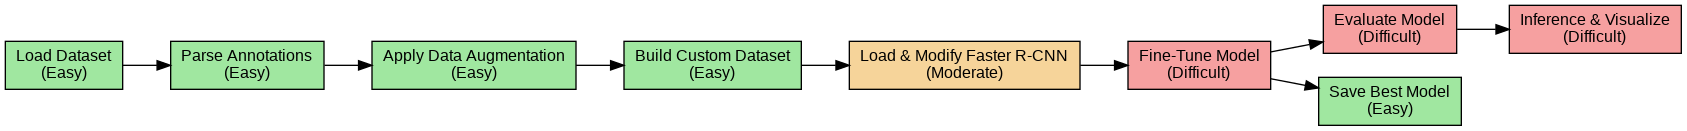

In [ ]:
IMG('faster_rcnn_flowchart.png')

## **The Penn-Fudan Pedestrian Detection Dataset**

For demonstration, we'll use the [Penn-Fudan Pedestrian Detection Dataset](https://www.cis.upenn.edu/~jshi/ped_html/). This dataset contains images of pedestrians with segmentation masks. However, **we only need bounding box annotations** for Faster R-CNN. This dataset includes both.

The **Penn-Fudan Dataset** is a lightweight dataset containing only **170 images**, with object classes limited to **`person`** and **`background`**. While it is possible to **fine-tune a Faster R-CNN model** on a larger dataset like **MS COCO** (which it was originally trained on), increasing the number of classes requires a **significantly larger dataset** to ensure proper representation.

An alternative is the **COCO128** dataset, a smaller subset of **MS COCO**, which can be used for **fine-tuning Faster R-CNN**. However, since **MS COCO** contains **80 object classes**, class representation in such a subset can be **highly imbalanced and sparse**.

For this tutorial, we will **use the Penn-Fudan dataset** because it is:
- **Simple** and easy to work with.
- **Computationally efficient** for training and evaluation.
- **Well-suited for demonstrating** the process of training a **Faster R-CNN model** without requiring excessive resources.

Let's load in our data **using Python**.

In [ ]:
root = './data'
url = 'https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip'
zip_name = 'PennFudanPed.zip'

if not os.path.exists(os.path.join(root, "PennFudanPed")):
    download_url(url, root)
    import zipfile
    with zipfile.ZipFile(os.path.join(root, zip_name), 'r') as zip_ref:
        zip_ref.extractall(root)
    print("Dataset extracted.")
else:
    print("Dataset already downloaded and extracted.")

100%|██████████| 53.7M/53.7M [00:01<00:00, 29.2MB/s]


Dataset extracted.


## **Showcasing our Dataset**

Since the **Penn-Fudan dataset** supports **instance segmentation**, each image is accompanied by its corresponding **segmentation mask**. However, since we are **not utilizing the mask head** of **Faster R-CNN**, these masks can be **omitted** for our task. Instead, we will focus solely on **bounding box detection**.

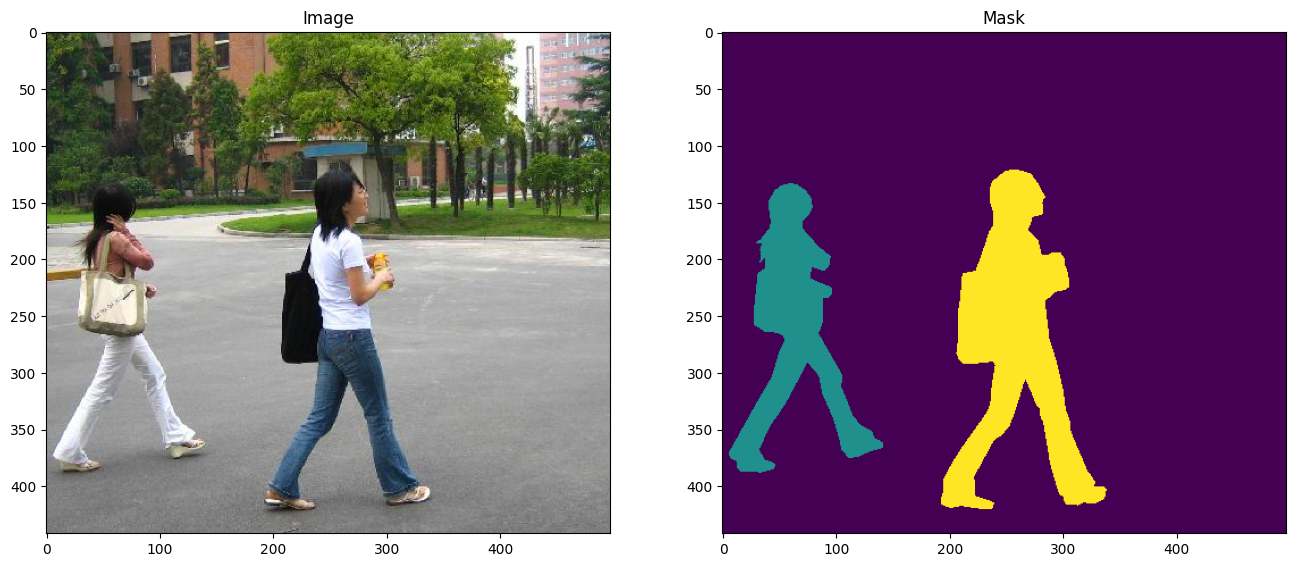

In [ ]:
image = read_image("/content/data/PennFudanPed/PNGImages/FudanPed00019.png")
mask = read_image("/content/data/PennFudanPed/PedMasks/FudanPed00019_mask.png")

plt.figure(figsize=(16, 8))
plt.subplot(121)
plt.title("Image")
plt.imshow(image.permute(1, 2, 0))
plt.subplot(122)
plt.title("Mask")
plt.imshow(mask.permute(1, 2, 0))
plt.show()

The annotation files for the **Penn-Fudan Pedestrian dataset** are **Pascal VOC-compatible** and follow a structured format. Each image located in `data/PennFudanPed/PNGImages/<ID>.png` has a corresponding annotation file in `data/PennFudanPed/Annotation/<ID>.txt`.  

Each annotation file contains **bounding box coordinates** and **class labels** for the objects in that specific image. The content of a typical annotation file is as follows:

```txt
# Compatible with PASCAL Annotation Version 1.00
Image filename : "PennFudanPed/PNGImages/FudanPed00001.png"
Image size (X x Y x C) : 559 x 536 x 3
Database : "The Penn-Fudan-Pedestrian Database"
Objects with ground truth : 2 { "PASpersonWalking" "PASpersonWalking" }
# Note there may be some objects not included in the ground truth list for they are severe-occluded
# or have very small size.
# Top left pixel coordinates : (1, 1)
# Details for pedestrian 1 ("PASpersonWalking")
Original label for object 1 "PASpersonWalking" : "PennFudanPed"
Bounding box for object 1 "PASpersonWalking" (Xmin, Ymin) - (Xmax, Ymax) : (160, 182) - (302, 431)
Pixel mask for object 1 "PASpersonWalking" : "PennFudanPed/PedMasks/FudanPed00001_mask.png"

# Details for pedestrian 2 ("PASpersonWalking")
Original label for object 2 "PASpersonWalking" : "PennFudanPed"
Bounding box for object 2 "PASpersonWalking" (Xmin, Ymin) - (Xmax, Ymax) : (420, 171) - (535, 486)
Pixel mask for object 2 "PASpersonWalking" : "PennFudanPed/PedMasks/FudanPed00001_mask.png"
```

Each annotation file provides detailed **bounding box** information for detected objects:

- Class label: *PASpersonWalking*
- Bounding box coordinates: (`xmin, ymin, xmax, ymax`)
- Segmentation mask file (not needed for Faster R-CNN without a mask head)


In [ ]:
def parse_annotation_file(annotation_path):
    """
    Parses a PennFudanPed annotation text file to extract bounding boxes and their labels.

    Args:
        annotation_path (str): Path to the annotation text file.

    Returns:
        List[Tuple[str, int, int, int, int]]: A list of tuples for each object in the format
            (object_label, xmin, ymin, xmax, ymax).
    """
    with open(annotation_path, 'r') as f:
        content = f.read()

    pattern = r'Bounding box for object \d+ "([^"]+)" \(Xmin, Ymin\) - \(Xmax, Ymax\) : \((\d+),\s*(\d+)\)\s*-\s*\((\d+),\s*(\d+)\)'
    matches = re.findall(pattern, content)
    boxes = [(label, int(xmin), int(ymin), int(xmax), int(ymax)) for label, xmin, ymin, xmax, ymax in matches]
    return boxes

def plot_image_with_annotations(image_path, annotation_path, ax):
    """
    Loads an image and its annotation, then plots the image on the given axis with bounding boxes and labels.

    Args:
        image_path (str): Path to the image file.
        annotation_path (str): Path to the corresponding annotation file.
        ax (matplotlib.axes.Axes): The axes on which to plot the image and annotations.
    """
    image = read_image(image_path)
    image_np = image.permute(1, 2, 0).cpu().numpy()
    boxes = parse_annotation_file(annotation_path)

    ax.imshow(image_np)
    ax.set_title(os.path.basename(image_path))

    for (label, xmin, ymin, xmax, ymax) in boxes:
        width = xmax - xmin
        height = ymax - ymin
        rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='cyan', facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin + 4, max(0, ymin - 6), label, fontsize=9, color='cyan',
                verticalalignment='bottom', bbox=dict(facecolor='black', alpha=0.7, edgecolor='none'))
    ax.axis('off')

In [ ]:
annotations_dir = '/content/data/PennFudanPed/Annotation'
images_dir = '/content/data/PennFudanPed/PNGImages'

annotation_files = sorted(glob.glob(os.path.join(annotations_dir, '*.txt')))
image_files = sorted(glob.glob(os.path.join(images_dir, '*.png')))

print("Number of annotation files: ", len(annotation_files))
print("Number of image files: ", len(image_files))

Number of annotation files:  170
Number of image files:  170


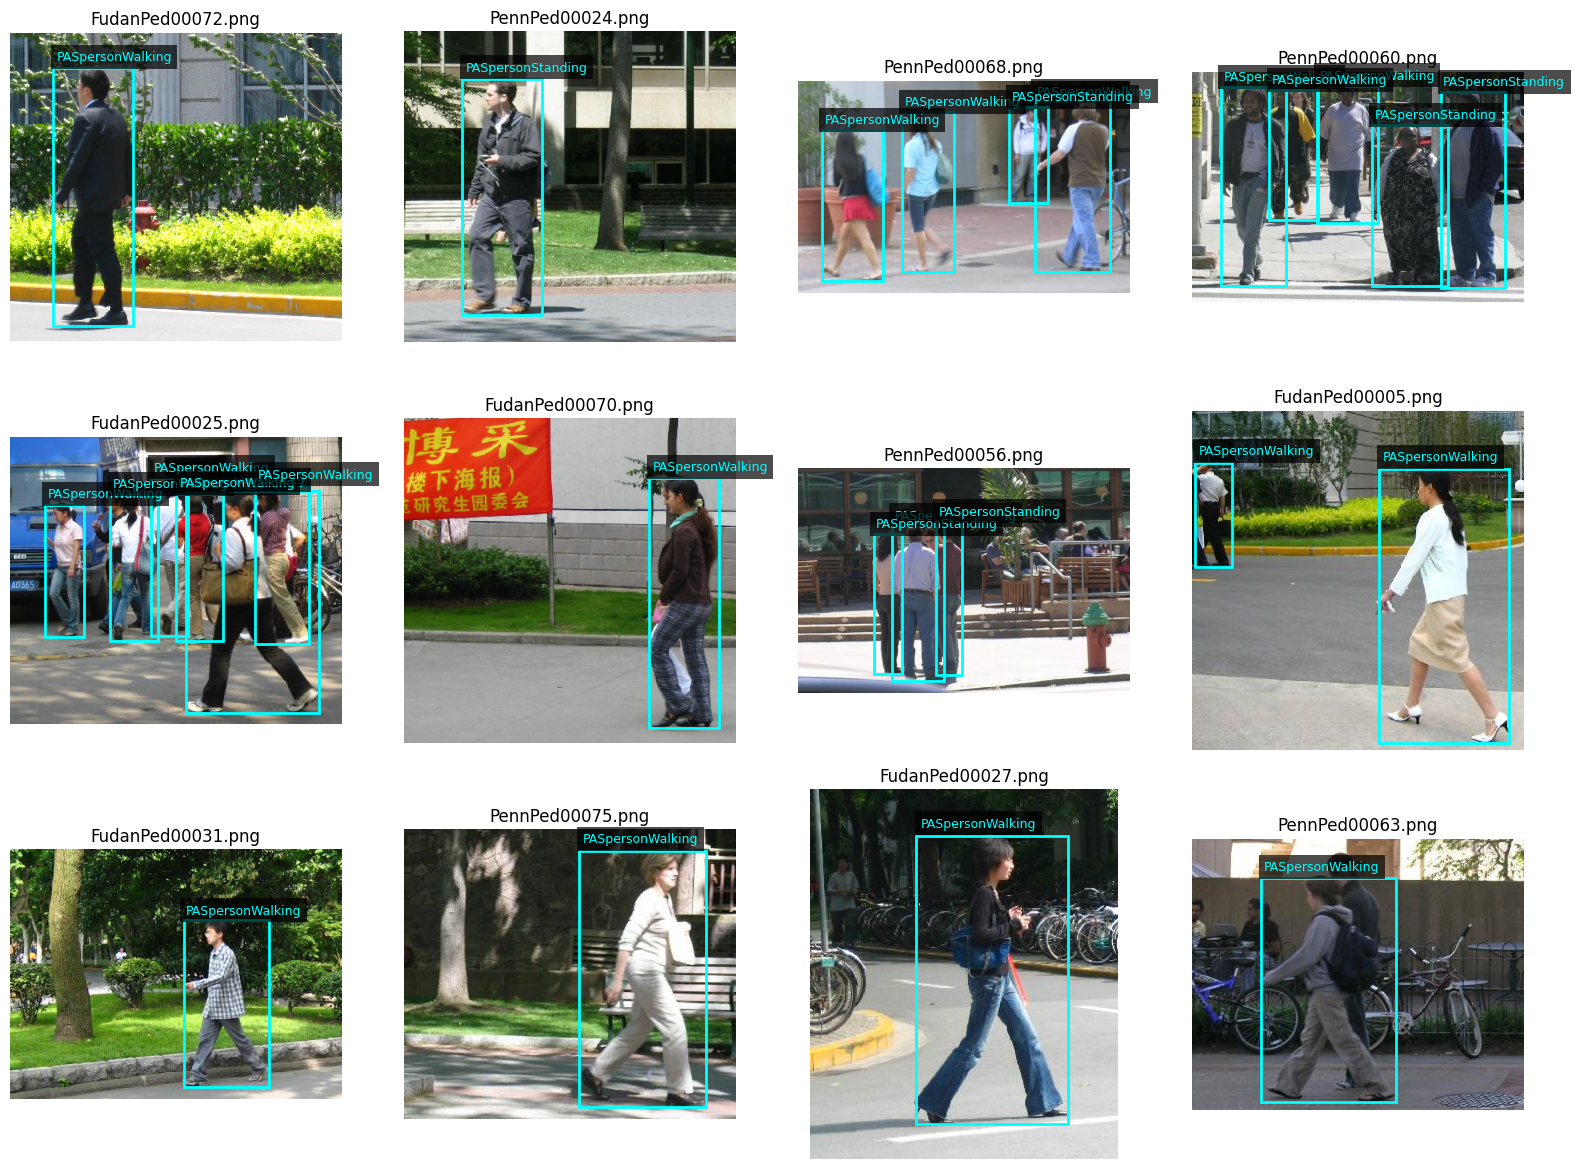

In [ ]:
classes = ['Background', 'PASpersonWalking']
label_mapping = {cls: i for i, cls in enumerate(classes)}

num_examples = 12
random_indices = random.sample(range(len(image_files)), 12)

selected_annotation_files = [annotation_files[i] for i in random_indices]
selected_image_files = [image_files[i] for i in random_indices]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(num_examples):
    plot_image_with_annotations(selected_image_files[i], selected_annotation_files[i], axes[i])

plt.tight_layout()
plt.show()

## **Creating a Dataset and Transformations**

We’ll create a custom dataset class (`PennFudanDatase`) that:
- Loads an image and corresponding **bounding boxes** (and labels).
- Applies transformations/augmentations (e.g., **random horizontal flips, resizing,** etc.).

We’ll define a few **transformations** for images and bounding boxes. For instance:

- **Convert** PIL images to tensors
- Random **horizontal flip** with some probability

In [ ]:
class PennFudanDataset(Dataset):
    def __init__(self, image_files, annotation_files, transforms=None):
        """
        Custom dataset that uses pre-loaded lists of image and annotation files.

        Args:
            image_files (list): Sorted list of image file paths.
            annotation_files (list): Sorted list of annotation file paths.
            transforms (callable, optional): A function/transform that takes in a PIL image and
                                             a target dict, and returns transformed versions.
        """
        assert len(image_files) == len(annotation_files), "Images and annotations lists must have the same length."
        self.image_files = image_files
        self.annotation_files = annotation_files
        self.transforms = transforms

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        annot_path = self.annotation_files[idx]

        img = Image.open(image_path).convert("RGB")
        boxes_and_labels = parse_annotation_file(annot_path)
        boxes = []
        labels = []
        for label_str, xmin, ymin, xmax, ymax in boxes_and_labels:
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label_mapping.get(label_str, 0))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        target = {"boxes": boxes, "labels": labels}

        if self.transforms is not None:
            img, target = self.transforms(img, target)
        return img, target

    def __len__(self):
        return len(self.image_files)

In [ ]:
class ComposeTransforms:
    """
    Composes a list of transformations to be applied sequentially to an image and its target.
    """
    def __init__(self, transforms_list):
        self.transforms_list = transforms_list

    def __call__(self, img, target):
        for t in self.transforms_list:
            img, target = t(img, target)
        return img, target

class ToTensor:
    """
    Converts a PIL image to a PyTorch tensor.
    """
    def __call__(self, img, target):
        img = TF.to_tensor(img)
        return img, target

class RandomHorizontalFlip:
    """
    Randomly horizontally flips an image and its bounding boxes with a given probability.
    """
    def __init__(self, flip_prob=0.5):
        self.flip_prob = flip_prob

    def __call__(self, img, target):
        if np.random.rand() < self.flip_prob:
            img = TF.hflip(img)
            boxes = target["boxes"]
            w = img.shape[2]
            boxes[:, [0, 2]] = w - boxes[:, [2, 0]]
            target["boxes"] = boxes
        return img, target

class ColorJitterTransform:
    """
    Randomly changes the brightness, contrast, saturation, and hue of an image.

    This transformation only modifies the image pixels and leaves the target (bounding boxes, etc.)
    unchanged.
    """
    def __init__(self, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1):
        self.jitter = T.ColorJitter(brightness=brightness, contrast=contrast,
                                    saturation=saturation, hue=hue)

    def __call__(self, img, target):
        img = self.jitter(img)
        return img, target

class GaussianBlurTransform:
    """
    Applies a Gaussian blur to the image.

    This transformation only affects the image pixels. The kernel_size and sigma
    can be adjusted to control the amount of blurring.
    """
    def __init__(self, kernel_size=3, sigma=(0.1, 2.0)):
        self.kernel_size = kernel_size
        self.sigma = sigma

    def __call__(self, img, target):
        img = TF.gaussian_blur(img, kernel_size=self.kernel_size, sigma=self.sigma)
        return img, target

class NormalizeTransform:
    def __init__(self, mean, std):
        self.normalize = T.Normalize(mean, std)

    def __call__(self, img, target):
        img = self.normalize(img)
        return img, target

## **Building the Dataset**

We will allocate the **Penn-Fudan dataset** into the following splits:
- **70%** for the **training set**  
- **15%** for the **validation set**  
- **15%** for the **test set**  

We **will not apply any transformations** to the test set. However, all images will be **normalized** to maintain consistency in input distributions across the training process.

In [ ]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = ComposeTransforms([
    ToTensor(),
    RandomHorizontalFlip(0.5),
    ColorJitterTransform(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    GaussianBlurTransform(kernel_size=5, sigma=(0.5, 1.5)),
    NormalizeTransform(mean, std)
])

test_transforms = ComposeTransforms([
    ToTensor(),
    NormalizeTransform(mean, std)
])

dataset_train_full = PennFudanDataset(image_files, annotation_files, transforms=train_transforms)
dataset_test_full  = PennFudanDataset(image_files, annotation_files, transforms=test_transforms)

num_total = len(dataset_train_full)

torch.manual_seed(42)
indices = torch.randperm(len(dataset_train_full)).tolist()

# There are 170 images in total only
train_end = int(0.7 * num_total)
valid_end = train_end + int(0.15 * num_total)

train_idx = indices[:train_end]
valid_idx = indices[train_end:valid_end]
test_idx  = indices[valid_end:]

dataset_train = Subset(dataset_train_full, train_idx)
dataset_valid = Subset(dataset_test_full, valid_idx)
dataset_test  = Subset(dataset_test_full, test_idx)

train_loader = DataLoader(dataset_train, batch_size=8, shuffle=True, num_workers=2, collate_fn=lambda x: tuple(zip(*x)))
valid_loader = DataLoader(dataset_valid, batch_size=8, shuffle=True, num_workers=2, collate_fn=lambda x: tuple(zip(*x)))
test_loader  = DataLoader(dataset_test, batch_size=8, shuffle=False, num_workers=2, collate_fn=lambda x: tuple(zip(*x)))

print(f"Number of training samples: {len(dataset_train)}")
print(f"Number of validation samples: {len(dataset_valid)}")
print(f"Number of testing samples: {len(dataset_test)}")


Number of training samples: 118
Number of validation samples: 25
Number of testing samples: 27


## **Visualizing our Transformed Samples**

To visualize our transformed samples using **`matplotlib`**, we need to **denormalize** the images so that they appear in their original form.  

We will implement a **dynamically scaling grid** that can adapt to **any number of training samples**, allowing for flexible visualization of multiple transformed images at once.

In [ ]:
def denormalize_image(img_tensor, mean, std):
    """
    Denormalizes a normalized image tensor.

    Args:
        img_tensor (torch.Tensor): Normalized image tensor of shape (C, H, W).
        mean (list or tuple): Mean values used for normalization.
        std (list or tuple): Std values used for normalization.

    Returns:
        torch.Tensor: Denormalized image tensor in range [0, 1].
    """
    mean = torch.tensor(mean).view(-1, 1, 1)
    std = torch.tensor(std).view(-1, 1, 1)
    denorm = img_tensor * std + mean
    denorm = torch.clamp(denorm, 0, 1)
    return denorm

def visualize_transformed_samples(dataset, num_samples, class_names, mean, std):
    """
    Visualizes a number of transformed samples from the dataset with bounding boxes and labels.
    Denormalizes the images before plotting.

    Args:
        dataset (Dataset): The dataset (or subset) from which to get samples.
        num_samples (int): The number of random samples to visualize.
        class_names (list): List of class names corresponding to label indices.
        mean (list): Mean values used for normalization.
        std (list): Std values used for normalization.
    """
    indices = random.sample(range(len(dataset)), num_samples)

    # try to make the grid roughly square
    n_cols = int(math.sqrt(num_samples))
    n_rows = math.ceil(num_samples / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 8 * n_rows))

    # Flatten axes array for easier iteration (if there's only one row/col, make it a list)
    if n_rows * n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, idx in enumerate(indices):
        img, target = dataset[idx]
        img_denorm = denormalize_image(img, mean, std)
        image_np = img_denorm.permute(1, 2, 0).cpu().numpy()

        axes[i].imshow(image_np)
        axes[i].set_title(f"Sample index: {idx}")

        boxes = target["boxes"]
        labels = target["labels"]

        for j, box in enumerate(boxes):
            xmin, ymin, xmax, ymax = box.tolist()
            width, height = xmax - xmin, ymax - ymin
            label_text = class_names[labels[j]]

            rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='cyan', facecolor='none')
            axes[i].add_patch(rect)
            axes[i].text(xmin + 4, max(0, ymin - 6), label_text, fontsize=12, color='cyan',
                         backgroundcolor='red', verticalalignment='bottom',
                         bbox=dict(facecolor='black', alpha=0.7, edgecolor='none'))
        axes[i].axis("off")

    # Turn off any extra subplots if num_samples doesn't fill the grid
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

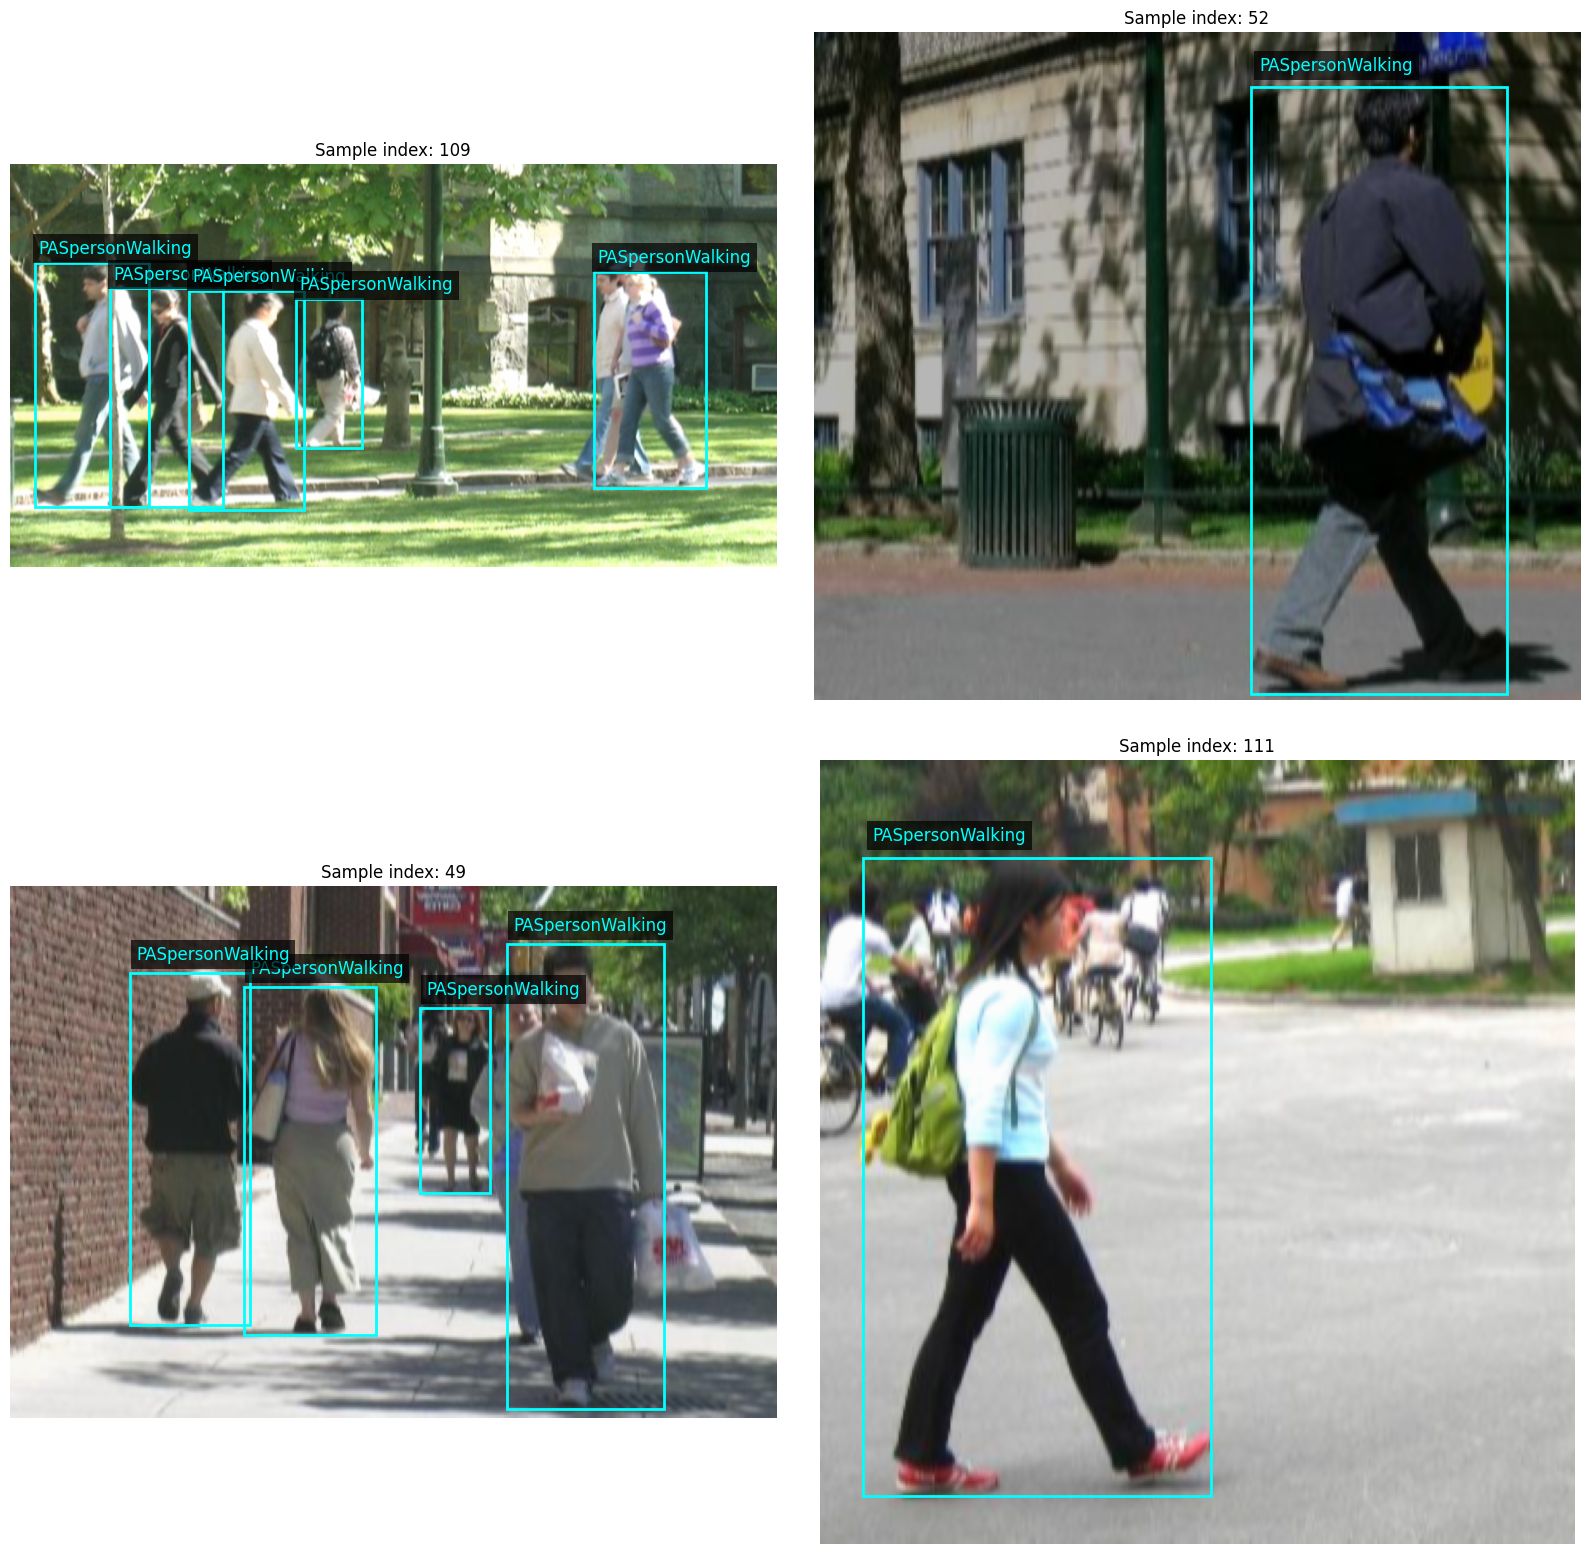

In [ ]:
visualize_transformed_samples(dataset_train, num_samples=4, class_names=classes, mean=mean, std=std)

## **Building the Fast R-CNN Model**

A **pre-trained Faster R-CNN model with a ResNet-50 backbone and Feature Pyramid Network (FPN)** is loaded from `torchvision`, initialized with default weights. The **classification head is replaced** to match the number of target classes by adjusting the fully connected layer in the `box_predictor`.

The model summary reveals that it includes a **built-in normalization layer** tailored for the **COCO dataset**. While our prior normalization step is not strictly necessary, it does not cause any issues—rather, it serves as a useful **exercise in preprocessing** that can be applied to other tasks where built-in normalization is not available.

In [ ]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
model

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 170MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
# Replace the classifier head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, len(classes))
model = model.to(device)
model

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
model.eval()
dummy_image = torch.randn(3, 300, 300).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(dummy_image)
    print("Model output:", output)

summary(model, input_data=dummy_image)

Model output: [{'boxes': tensor([[2.8041e+00, 2.0822e+02, 6.4758e+00, 2.1313e+02],
        [2.0548e+02, 0.0000e+00, 2.2659e+02, 2.0755e+01],
        [2.7085e+00, 5.1888e+01, 6.1349e+00, 5.5093e+01],
        [6.8275e+01, 1.7613e+02, 7.0763e+01, 1.7971e+02],
        [2.6474e+02, 8.8431e-02, 2.8990e+02, 2.1902e+01],
        [2.0412e+00, 5.0108e+01, 5.8884e+00, 5.4168e+01],
        [2.9318e+02, 1.6351e+02, 2.9576e+02, 1.6717e+02],
        [6.9321e+01, 1.7614e+02, 7.2219e+01, 1.7983e+02],
        [2.3286e+02, 7.4405e+01, 2.3677e+02, 7.7722e+01],
        [1.6058e+02, 1.4452e+01, 1.6444e+02, 1.8079e+01],
        [2.7661e+02, 1.6514e+02, 2.8025e+02, 1.6891e+02],
        [6.4962e+01, 1.7185e+02, 6.7984e+01, 1.7589e+02],
        [1.6175e+02, 1.5570e+01, 1.6580e+02, 1.9257e+01],
        [6.3076e+01, 1.7309e+02, 6.6764e+01, 1.7625e+02],
        [2.8055e+02, 9.2166e+01, 2.8438e+02, 9.6353e+01],
        [2.8750e+02, 1.5853e+01, 2.9008e+02, 1.9472e+01],
        [5.5493e+01, 2.1037e+02, 7.8340e+01, 2.

Layer (type:depth-idx)                                  Output Shape              Param #
FasterRCNN                                              [100, 4]                  --
├─GeneralizedRCNNTransform: 1-1                         [1, 3, 800, 800]          --
├─BackboneWithFPN: 1-2                                  [1, 256, 13, 13]          --
│    └─IntermediateLayerGetter: 2-1                     [1, 2048, 25, 25]         --
│    │    └─Conv2d: 3-1                                 [1, 64, 400, 400]         (9,408)
│    │    └─FrozenBatchNorm2d: 3-2                      [1, 64, 400, 400]         --
│    │    └─ReLU: 3-3                                   [1, 64, 400, 400]         --
│    │    └─MaxPool2d: 3-4                              [1, 64, 200, 200]         --
│    │    └─Sequential: 3-5                             [1, 256, 200, 200]        (212,992)
│    │    └─Sequential: 3-6                             [1, 512, 100, 100]        1,212,416
│    │    └─Sequential: 3-7              

## **Training**

For fine-tuning, we use a **small batch size of 4** to accommodate the **memory constraints of a T4 GPU**. **SGD (Stochastic Gradient Descent)** is chosen as the optimizer, as it is well-suited for **small-scale fine-tuning tasks**, providing stable updates and better generalization. All **trainable parameters** (`requires_grad=True`) are optimized to allow effective adaptation of the pre-trained model.

In [ ]:
for name, param in model.named_parameters():
    print(f"{name}: requires_grad = {param.requires_grad}")

for param in model.backbone.body.layer2.parameters():
    param.requires_grad = False

params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

backbone.body.conv1.weight: requires_grad = False
backbone.body.layer1.0.conv1.weight: requires_grad = False
backbone.body.layer1.0.conv2.weight: requires_grad = False
backbone.body.layer1.0.conv3.weight: requires_grad = False
backbone.body.layer1.0.downsample.0.weight: requires_grad = False
backbone.body.layer1.1.conv1.weight: requires_grad = False
backbone.body.layer1.1.conv2.weight: requires_grad = False
backbone.body.layer1.1.conv3.weight: requires_grad = False
backbone.body.layer1.2.conv1.weight: requires_grad = False
backbone.body.layer1.2.conv2.weight: requires_grad = False
backbone.body.layer1.2.conv3.weight: requires_grad = False
backbone.body.layer2.0.conv1.weight: requires_grad = True
backbone.body.layer2.0.conv2.weight: requires_grad = True
backbone.body.layer2.0.conv3.weight: requires_grad = True
backbone.body.layer2.0.downsample.0.weight: requires_grad = True
backbone.body.layer2.1.conv1.weight: requires_grad = True
backbone.body.layer2.1.conv2.weight: requires_grad = Tru

In [ ]:
def print_epoch_summary(epoch, train_loss, train_loss_classifier, train_loss_box_reg,
                        train_loss_objectness, train_loss_rpn_box_reg,
                        val_loss, val_loss_classifier, val_loss_box_reg,
                        val_loss_objectness, val_loss_rpn_box_reg, epoch_time):
    print(f"\nEpoch [{epoch+1}] Summary:")
    print("----------------------------------------------------------")
    print(f"Training Loss: {train_loss:.4f}")
    print(f"   Classifier Loss: {train_loss_classifier:.4f}")
    print(f"   Box Regression Loss: {train_loss_box_reg:.4f}")
    print(f"   Objectness Loss: {train_loss_objectness:.4f}")
    print(f"   RPN Box Regression Loss: {train_loss_rpn_box_reg:.4f}")
    print("----------------------------------------------------------")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"   Classifier Loss: {val_loss_classifier:.4f}")
    print(f"   Box Regression Loss: {val_loss_box_reg:.4f}")
    print(f"   Objectness Loss: {val_loss_objectness:.4f}")
    print(f"   RPN Box Regression Loss: {val_loss_rpn_box_reg:.4f}")
    print("==========================================================")
    print(f"Epoch Time: {epoch_time:.2f} sec\n")

The built-in `fasterrcnn_resnet50_fpn` model includes an **integrated loss function** that computes a **composite loss** based on four key components:  

- **Classifier Loss**: Measures classification errors for detected objects.  
- **Box Regression Loss**: Evaluates how well the predicted bounding boxes align with ground truth.  
- **Objectness Loss**: Determines whether a region proposal contains an object.  
- **RPN Box Regression Loss**: Assesses the accuracy of region proposal bounding boxes.  

When using this model, we do not need to manually define a loss function. In **training mode**, the model automatically returns a **loss dictionary** instead of standard outputs, allowing us to track running losses. In **evaluation mode**, the model outputs **predictions** rather than loss values.

In [ ]:
num_epochs = 10
model.train()

best_val_loss = float('inf')

# Histories
train_loss_history = []
train_loss_classifier_history = []
train_loss_box_reg_history = []
train_loss_objectness_history = []
train_loss_rpn_box_reg_history = []
val_loss_history = []
val_loss_classifier_history = []
val_loss_box_reg_history = []
val_loss_objectness_history = []
val_loss_rpn_box_reg_history = []

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()

    train_loss = 0.0
    train_loss_classifier = 0.0
    train_loss_box_reg = 0.0
    train_loss_objectness = 0.0
    train_loss_rpn_box_reg = 0.0
    train_samples = 0

    # --------------------- Training Loop --------------------- #
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)

        loss_classifier = loss_dict['loss_classifier']
        loss_box_reg = loss_dict['loss_box_reg']
        loss_objectness = loss_dict['loss_objectness']
        loss_rpn_box_reg = loss_dict['loss_rpn_box_reg']

        losses = loss_classifier + loss_box_reg + loss_objectness + loss_rpn_box_reg

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        batch_size = len(images)
        train_loss += losses.item() * batch_size
        train_loss_classifier += loss_classifier.item() * batch_size
        train_loss_box_reg += loss_box_reg.item() * batch_size
        train_loss_objectness += loss_objectness.item() * batch_size
        train_loss_rpn_box_reg += loss_rpn_box_reg.item() * batch_size
        train_samples += batch_size

    # Average training losses
    train_loss /= train_samples
    train_loss_classifier /= train_samples
    train_loss_box_reg /= train_samples
    train_loss_objectness /= train_samples
    train_loss_rpn_box_reg /= train_samples

    train_loss_history.append(train_loss)
    train_loss_classifier_history.append(train_loss_classifier)
    train_loss_box_reg_history.append(train_loss_box_reg)
    train_loss_objectness_history.append(train_loss_objectness)
    train_loss_rpn_box_reg_history.append(train_loss_rpn_box_reg)

    # --------------------- Validation Loop --------------------- #
    # Use torch.no_grad() during validation to save memory.
    model.train()  # Still need to be in train mode for loss computation with targets.
    val_loss = 0.0
    val_loss_classifier = 0.0
    val_loss_box_reg = 0.0
    val_loss_objectness = 0.0
    val_loss_rpn_box_reg = 0.0
    val_samples = 0

    with torch.no_grad():
        for images, targets in valid_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            loss_classifier = loss_dict['loss_classifier']
            loss_box_reg = loss_dict['loss_box_reg']
            loss_objectness = loss_dict['loss_objectness']
            loss_rpn_box_reg = loss_dict['loss_rpn_box_reg']

            batch_size = len(images)
            val_loss += losses.item() * batch_size
            val_loss_classifier += loss_classifier.item() * batch_size
            val_loss_box_reg += loss_box_reg.item() * batch_size
            val_loss_objectness += loss_objectness.item() * batch_size
            val_loss_rpn_box_reg += loss_rpn_box_reg.item() * batch_size
            val_samples += batch_size

    val_loss /= val_samples
    val_loss_classifier /= val_samples
    val_loss_box_reg /= val_samples
    val_loss_objectness /= val_samples
    val_loss_rpn_box_reg /= val_samples

    val_loss_history.append(val_loss)
    val_loss_classifier_history.append(val_loss_classifier)
    val_loss_box_reg_history.append(val_loss_box_reg)
    val_loss_objectness_history.append(val_loss_objectness)
    val_loss_rpn_box_reg_history.append(val_loss_rpn_box_reg)

    lr_scheduler.step()

    epoch_time = time.time() - start_time
    print_epoch_summary(epoch, train_loss, train_loss_classifier, train_loss_box_reg,
                        train_loss_objectness, train_loss_rpn_box_reg,
                        val_loss, val_loss_classifier, val_loss_box_reg,
                        val_loss_objectness, val_loss_rpn_box_reg, epoch_time)

    torch.cuda.empty_cache()

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model_frcnn.pth')
        print("Saved best model.")


Epoch [1] Summary:
----------------------------------------------------------
Training Loss: 0.4623
   Classifier Loss: 0.2002
   Box Regression Loss: 0.1897
   Objectness Loss: 0.0541
   RPN Box Regression Loss: 0.0182
----------------------------------------------------------
Validation Loss: 0.2964
   Classifier Loss: 0.1049
   Box Regression Loss: 0.1591
   Objectness Loss: 0.0193
   RPN Box Regression Loss: 0.0131
Epoch Time: 36.92 sec

Saved best model.

Epoch [2] Summary:
----------------------------------------------------------
Training Loss: 0.3355
   Classifier Loss: 0.1085
   Box Regression Loss: 0.1939
   Objectness Loss: 0.0171
   RPN Box Regression Loss: 0.0159
----------------------------------------------------------
Validation Loss: 0.2334
   Classifier Loss: 0.0638
   Box Regression Loss: 0.1451
   Objectness Loss: 0.0128
   RPN Box Regression Loss: 0.0117
Epoch Time: 36.08 sec

Saved best model.

Epoch [3] Summary:
--------------------------------------------------

#### **Saving our Model**

In [ ]:
model_save_path = 'best_model_frcnn.pth'

# Save the model's state dictionary
torch.save(model.state_dict(), model_save_path)

#### **Plotting Losses**

In [ ]:
def plot_losses(train_loss_history, train_loss_classifier_history, train_loss_box_reg_history,
                train_loss_objectness_history, train_loss_rpn_box_reg_history,
                val_loss_history, val_loss_classifier_history, val_loss_box_reg_history,
                val_loss_objectness_history, val_loss_rpn_box_reg_history):
    """
    Plots training and validation loss histories for overall loss and each individual loss component.

    Args:
        train_loss_history (list): Overall training loss per epoch.
        train_loss_classifier_history (list): Training classifier loss per epoch.
        train_loss_box_reg_history (list): Training box regression loss per epoch.
        train_loss_objectness_history (list): Training objectness loss per epoch.
        train_loss_rpn_box_reg_history (list): Training RPN box regression loss per epoch.
        val_loss_history (list): Overall validation loss per epoch.
        val_loss_classifier_history (list): Validation classifier loss per epoch.
        val_loss_box_reg_history (list): Validation box regression loss per epoch.
        val_loss_objectness_history (list): Validation objectness loss per epoch.
        val_loss_rpn_box_reg_history (list): Validation RPN box regression loss per epoch.
    """
    epochs = range(1, len(train_loss_history) + 1)
    plt.figure(figsize=(12, 8))

    # Plot overall loss
    plt.plot(epochs, train_loss_history, 'b-', label='Train Overall Loss')
    plt.plot(epochs, val_loss_history, 'b--', label='Val Overall Loss')

    # Plot classifier loss
    plt.plot(epochs, train_loss_classifier_history, 'r-', label='Train Classifier Loss')
    plt.plot(epochs, val_loss_classifier_history, 'r--', label='Val Classifier Loss')

    # Plot box regression loss
    plt.plot(epochs, train_loss_box_reg_history, 'g-', label='Train Box Reg Loss')
    plt.plot(epochs, val_loss_box_reg_history, 'g--', label='Val Box Reg Loss')

    # Plot objectness loss
    plt.plot(epochs, train_loss_objectness_history, 'c-', label='Train Objectness Loss')
    plt.plot(epochs, val_loss_objectness_history, 'c--', label='Val Objectness Loss')

    # Plot RPN box regression loss
    plt.plot(epochs, train_loss_rpn_box_reg_history, 'm-', label='Train RPN Box Reg Loss')
    plt.plot(epochs, val_loss_rpn_box_reg_history, 'm--', label='Val RPN Box Reg Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Losses per Epoch')
    plt.legend()
    plt.grid(True)
    plt.show()

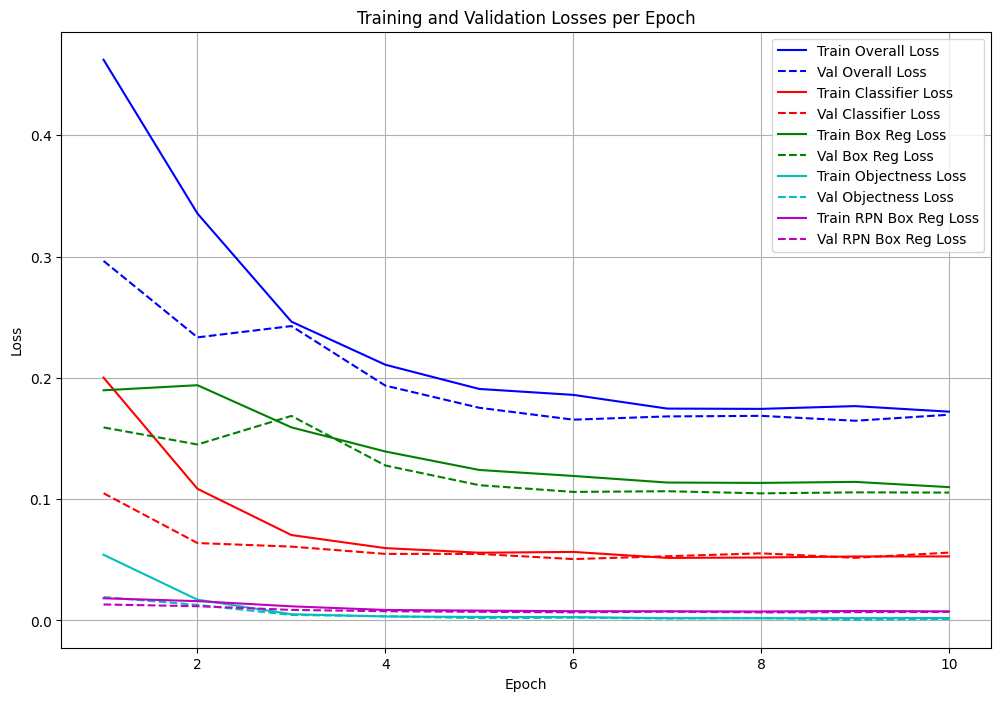

In [ ]:
plot_losses(train_loss_history, train_loss_classifier_history, train_loss_box_reg_history,
            train_loss_objectness_history, train_loss_rpn_box_reg_history,
            val_loss_history, val_loss_classifier_history, val_loss_box_reg_history,
            val_loss_objectness_history, val_loss_rpn_box_reg_history)

The plot demonstrates that the **pre-trained Faster R-CNN model** was already highly effective at detecting **person bounding boxes** in images. This is because the **pre-trained weights** were trained on a **large-scale dataset (e.g., COCO)** that includes similar images of people walking. As a result, our **fine-tuning did not yield significant improvements**, since the model was already well-suited for the task.

#### **Loading in the Model**

In [ ]:
model.load_state_dict(torch.load('best_model_frcnn.pth'))
model.eval()

<ipython-input-22-1ddb19c98d52>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model_frcnn.pth'))


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

## **Testing our Model**

For testing purposes, we will compute the **mean Average Precision (mAP)** at different **Intersection over Union (IoU) thresholds**. The function **`compute_iou`** calculates the **IoU values**, while **`evaluate_predictions`** computes the **mAP** at a specified **IoU threshold**.

The **IoU** between two bounding boxes is computed as:

$$
IoU = \frac{|A \cap B|}{|A \cup B|}
$$

where:
- $A$ and $B$ are the predicted and ground truth bounding boxes, respectively.
- $|A \cap B|$ represents the **area of intersection** between the two bounding boxes.
- $|A \cup B|$ represents the **area of their union**.

The **Average Precision (AP)** at a given IoU threshold is computed as:

$$
AP = \sum_n (R_n - R_{n-1}) P_n
$$

where:
- $P_n$ and $R_n$ are the **precision** and **recall** at the $n^{th}$ threshold, respectively.

The **mean Average Precision (mAP)** is then obtained by averaging the **AP values** across multiple **IoU thresholds**:

$$
mAP = \frac{1}{T} \sum_{t=1}^{T} AP_{IoU_t}
$$

where:
- $T$ is the total number of IoU thresholds.
- $AP_{IoU_t}$ is the **AP** at the **$t^{th}$ IoU threshold**.

This metric provides a comprehensive evaluation of the model's detection performance across varying degrees of localization accuracy.

A prediction looks like the following:

```python
{'boxes': tensor([[119.7279,  45.0536, 244.8307, 332.0854],
        [115.9338,  62.2116, 179.0104, 319.6712],
        [144.6216,  50.3902, 217.2193, 209.9409],
        [  1.6695,  52.2323,  22.4929, 112.4107],
        [108.8810,  67.1334, 173.3511, 201.6209]], device='cuda:0'), 'labels': tensor([1, 1, 1, 1, 1], device='cuda:0'), 'scores': tensor([0.9802, 0.5823, 0.3677, 0.2806, 0.0934], device='cuda:0')}
```

In [ ]:
def compute_iou(box1, box2):
    """
    Compute Intersection over Union (IoU) between two boxes.

    Args:
        box1 (array-like): [x1, y1, x2, y2] for the first box.
        box2 (array-like): [x1, y1, x2, y2] for the second box.

    Returns:
        float: IoU value.
    """
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    interArea = interW * interH
    box1Area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2Area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    unionArea = box1Area + box2Area - interArea
    iou = interArea / unionArea if unionArea > 0 else 0
    return iou

def evaluate_detections(predictions, ground_truths, iou_threshold=0.5):
    """
    Evaluates detections for non-background classes and computes a simplified average precision (AP)
    at the given IoU threshold. The background class (label 0) is ignored.

    Args:
        predictions (list): List of dicts for each image with keys 'boxes', 'scores', and 'labels'.
        ground_truths (list): List of dicts for each image with keys 'boxes' and 'labels'.
        iou_threshold (float): IoU threshold for considering a prediction as a true positive.

    Returns:
        tuple: (ap_per_class, mAP) where ap_per_class is a dict mapping class labels (non-zero)
               to their average precision, and mAP is the mean average precision over those classes.
    """
    pred_by_class = {}
    gt_by_class = {}

    for preds, gts in zip(predictions, ground_truths):
        # Gets all the unique labels in an image (Here: 0 and 1)
        labels_in_image = np.unique(np.concatenate([preds['labels'].cpu().numpy(), gts['labels'].cpu().numpy()]))
        for label in labels_in_image:
            if label == 0:
                continue  # Skip background

            # If label is not already a key in pred_by_class or gt_by_class, it adds that key with an empty list as its value
            pred_by_class.setdefault(label, [])
            gt_by_class.setdefault(label, [])

            # For predictions: store each detection as (score, box, matched flag)
            # Get all label indices that match our pedestrian label
            inds = (preds['labels'] == label).nonzero().squeeze(1)
            # Store all predictions for that label in a dict
            for idx in inds:
                pred_by_class[label].append({
                    'score': preds['scores'][idx].item(),
                    'box': preds['boxes'][idx].cpu().numpy(),
                    'matched': False
                })
            # For ground truths: simply store each box
            inds = (gts['labels'] == label).nonzero().squeeze(1)
            for idx in inds:
                gt_by_class[label].append(gts['boxes'][idx].cpu().numpy())

    ap_per_class = {}
    for label in gt_by_class.keys():
        # Sort predictions by decreasing score for a specific label
        preds = sorted(pred_by_class[label], key=lambda x: x['score'], reverse=True)

        # Number of ground truths for a specific label
        num_gt = len(gt_by_class[label])

        # Set True Positives and False Positives to 0
        tp = np.zeros(len(preds))
        fp = np.zeros(len(preds))

        # Compute IoU for GT bbox and PRED bbox
        # We iterate through the ground truth bboxes for the label
        # We find the best match for it (based on Iou)
        # If the match has not been marked before, then we set the match to True
        # Then increase TP by 1
        for i, pred in enumerate(preds):
            best_iou = 0
            for gt_box in gt_by_class[label]:
                iou = compute_iou(pred['box'], gt_box)
                if iou > best_iou:
                    best_iou = iou
            if best_iou >= iou_threshold:
                if not pred['matched']:
                    tp[i] = 1
                    pred['matched'] = True
                else:
                    fp[i] = 1
            else:
                fp[i] = 1

        # Compute cumulative sums
        tp_cumsum = np.cumsum(tp)
        fp_cumsum = np.cumsum(fp)

        # Calculating Prec and Recall
        precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-10)
        recalls = tp_cumsum / (num_gt + 1e-10)

        # Simplified AP calculation: average precision at fixed recall thresholds
        # 20-point interpolation approximation of Average Precision (AP)
        # It generates 20 evenly spaced recall thresholds between 0 and 1
        # For each threshold, it finds the maximum precision value achieved at any recall level greater than or equal to that threshold
        # It sums these maximum precision values and divides by 20 to obtain the average
        ap = 0
        for r_thresh in np.linspace(0, 1, 20):
            precisions_at_recall = precisions[recalls >= r_thresh]
            if precisions_at_recall.size > 0:
                ap += np.max(precisions_at_recall)
        ap /= 20.0
        ap_per_class[label] = ap

    mAP = np.mean(list(ap_per_class.values()))
    return ap_per_class, mAP

#### **Inferring our Whole Test Set**

In [ ]:
all_predictions = []
all_ground_truths = []
with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        preds = model(images)
        all_predictions.extend(preds)
        all_ground_truths.extend(targets)

#### **Computing IoU**

In [ ]:
ap_per_class, mAP = evaluate_detections(all_predictions, all_ground_truths, iou_threshold=0.5)
print("Average Precision per class:", ap_per_class)
print(f"Mean Average Precision (mAP) @ IoU 0.5: {mAP:.4f}\n")

ap_per_class, mAP = evaluate_detections(all_predictions, all_ground_truths, iou_threshold=0.9)
print("Average Precision per class:", ap_per_class)
print(f"Mean Average Precision (mAP) @ IoU 0.9: {mAP:.4f}")

Average Precision per class: {1: 0.9874125874095974}
Mean Average Precision (mAP) @ IoU 0.5: 0.9874

Average Precision per class: {1: 0.09788934897105692}
Mean Average Precision (mAP) @ IoU 0.9: 0.0979


#### **Visualizing Results**

In [ ]:
def visualize_detections(image, predictions, ground_truth, class_names, threshold=0.5):
    """
    Visualizes the predicted and ground truth bounding boxes on the image.

    Args:
        image (np.ndarray): Image array in [H, W, 3] format.
        predictions (dict): Dictionary with keys 'boxes', 'labels', 'scores' from the model.
        ground_truth (dict): Dictionary with keys 'boxes', 'labels'.
        class_names (list): List of class names.
        threshold (float): Score threshold to display a prediction.
    """
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    # Draw ground truth boxes in cyan
    for box, label in zip(ground_truth['boxes'], ground_truth['labels']):
        x1, y1, x2, y2 = box.cpu().numpy()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='cyan', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1 + 4, max(0, y1 - 4), f"GT: {class_names[label.item()]}", color='cyan', fontsize=9, verticalalignment='bottom', bbox=dict(facecolor='black', alpha=0.7, edgecolor='none'))

    # Draw predicted boxes in orange (if above score threshold)
    for box, label, score in zip(predictions['boxes'], predictions['labels'], predictions['scores']):
        if score.item() < threshold:
            continue
        x1, y1, x2, y2 = box.cpu().numpy()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='orange', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1 + 4, max(0, y2 - 4), f"Pred: {class_names[label.item()]} ({score.item():.2f})", color='orange', fontsize=9, verticalalignment="bottom", bbox=dict(facecolor='black', alpha=0.7, edgecolor='none'))

    plt.axis('off')
    plt.title("Detections: Green = Ground Truth, Red = Predictions")
    plt.show()

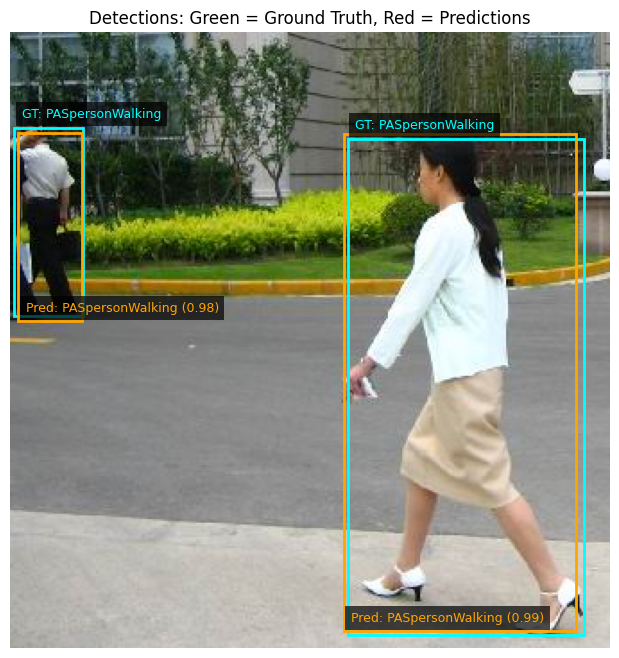

In [ ]:
sample_idx = random.randint(0, len(dataset_test) - 1)
sample_image, sample_target = dataset_test[sample_idx]

denorm_sample_image = denormalize_image(sample_image, mean, std)
denorm_sample_image = denorm_sample_image.permute(1, 2, 0).cpu().numpy()
denorm_sample_image = (denorm_sample_image * 255).astype(np.uint8)

with torch.no_grad():
    prediction = model([sample_image.to(device)])

sample_pred = prediction[0]
sample_gt = sample_target

visualize_detections(denorm_sample_image, sample_pred, sample_gt, classes, threshold=0.9)

### **HOMEWORK (Optional)**

- **Exercise 1: Using a Larger Dataset (MS COCO)**  
  Instead of using the Penn-Fudan dataset, try training the Faster R-CNN model on the **MS COCO dataset**. Since MS COCO contains **80 different object classes**, you will need to adjust the **classification head** accordingly.

- **Exercise 2: Data Augmentation for Object Detection**  
  Modify the **data augmentation pipeline** to include additional transformations such as **RandomAffine**, **RandomRotation**, or **RandomErasing**.

- **Exercise 3: Adjusting IoU Thresholds for mAP Calculation**  
  Modify the **IoU threshold values** for mAP calculation and compare the results. Try thresholds of **0.3, 0.5, 0.7, and 0.9**, and observe how the model's precision and recall change at different levels of localization accuracy.

- **Exercise 4: Optimizer and Learning Rate Scheduling**  
  Experiment with different optimizers, such as **Adam**, **AdamW**, and **RMSprop**, in place of **SGD**.

- **Exercise 5: Transfer Learning with Alternative Backbones**  
  Replace the **ResNet-50** backbone with another architecture, such as **ResNet-101** or **MobileNetV2**.

- **Exercise 6: Implementing Non-Maximum Suppression (NMS) Manually**  
  The Faster R-CNN model includes **built-in Non-Maximum Suppression (NMS)** to remove redundant bounding boxes. Implement your own **NMS function** and compare its results with the built-in implementation.